# Session 4 &mdash; ML Foundations I: Gradient Descent & Logistic Regression
**Data Science Techniques and Real-World Applications &mdash; WS 2026**

**Zahra Sharafi**

**Frankfurt School of Finance and Management**

Thursday 1 October 2026 

Everything so far (t-tests, regression, causality) has been about understanding relationships in
data you already have. Today we start **machine learning**: still fitting models to data, but with
a sharper focus on *how* the fitting actually happens (gradient descent) and on a new kind of
outcome &mdash; not a number, but a category (classification, via logistic regression).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression

df = pd.read_excel("data/techstocks.xlsx", sheet_name="main")
df = df.rename(columns={"Return on the S&P 500 Index": "MktReturn"})
df.head()

,PERMNO,Names Date,Ticker Symbol,Company Name,Price or Bid/Ask Average,Returns,MktReturn
0,14542,2018-01-02,GOOG,ALPHABET INC,1065.000000,0.017775,0.008303
1,14542,2018-01-03,GOOG,ALPHABET INC,1082.479980,0.016413,0.006399
2,14542,2018-01-04,GOOG,ALPHABET INC,1086.400024,0.003621,0.004029
3,14542,2018-01-05,GOOG,ALPHABET INC,1102.229980,0.014571,0.007034
4,14542,2018-01-08,GOOG,ALPHABET INC,1106.939941,0.004273,0.001662


## <span style="color:#1e3a8a">What is machine learning?</span>

> "A computer program is said to learn from experience $E$ with respect to some class of tasks $T$
> and performance measure $P$, if its performance at tasks in $T$, as measured by $P$, improves
> with experience $E$." &mdash; Tom Mitchell

Three ingredients, every time:
- **Task ($T$)**: what you're trying to do &mdash; regression, classification, pattern discovery.
- **Experience ($E$)**: the data the algorithm learns from &mdash; **supervised** (labeled), **unsupervised**
  (unlabeled), or **reinforcement** (learned by interacting with an environment).
- **Performance measure ($P$)**: a number that says how well the model is doing, which the fitting
  procedure tries to optimize.

Under this definition, the regression from Session 3 was already machine learning: task =
predict returns, experience = labeled historical data, performance = fit (minimize squared
residuals). What's new today is *how* we do the optimizing, and a new task (classification).

## <span style="color:#1e3a8a">From OLS to gradient descent</span>

In Session 3, `statsmodels` handed us the OLS coefficients directly, using a closed-form formula.
That formula only exists for linear regression. Most machine learning models (logistic regression,
neural networks, and everything built on them) have no such shortcut &mdash; instead, we **search**
for the parameters that minimize a cost function, one small step at a time. That search procedure
is **gradient descent**, and it's arguably the single most important algorithm in modern ML.

**The idea, in one sentence:** gradient descent is walking downhill in the fog &mdash; you can't see
the valley floor, but you can feel which way is down, so you take a step that way and repeat.

- **Cost function**: how wrong the model currently is (for regression, usually mean squared error).
- **Parameters**: the values we're searching over (e.g. $a$ and $b$ in $y = a + bx$).
- **Gradient**: the direction of steepest *increase* in the cost function &mdash; so we step in the
  *opposite* direction.
- **Learning rate**: how big a step to take each time.

**The loop:**
1. Start with some (often random or zero) parameter values.
2. Compute the gradient of the cost function at the current parameters.
3. Update the parameters by moving a small step opposite the gradient.
4. Repeat until the cost stops improving (much).

### A quick illustration first: what are we even minimizing?

"Fit a line" means: for every candidate line, measure how far off it is at each point (the gray
segments below), square each of those distances, and average them &mdash; that average is the
**mean squared error (MSE)**. The best line is simply whichever one makes this average as small as
possible. Gradient descent is just a systematic way of searching for that line, step by step.

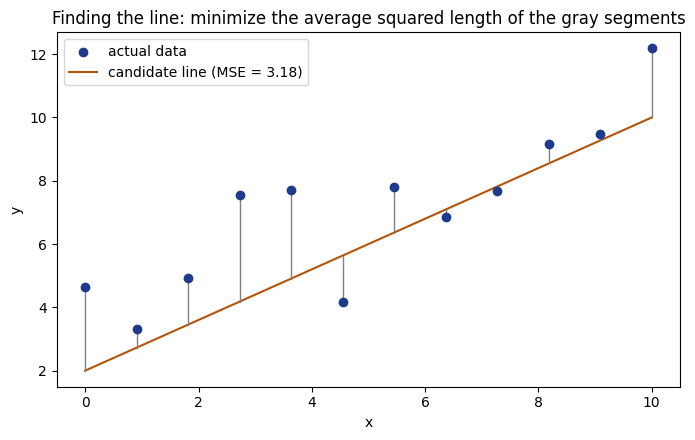

In [2]:
np.random.seed(0)
x_demo = np.linspace(0, 10, 12)
y_demo = 2 + 0.8 * x_demo + np.random.normal(0, 1.5, size=len(x_demo))

a_demo, b_demo = 2, 0.8                      # a candidate line
y_pred_demo = a_demo + b_demo * x_demo
mse_demo = np.mean((y_pred_demo - y_demo) ** 2)   # average of the squared gray segments below

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_demo, y_demo, color="#1e3a8a", zorder=3, label="actual data")
ax.plot(x_demo, y_pred_demo, color="#b45309", label=f"candidate line (MSE = {mse_demo:.2f})")
for xi, yi, ypi in zip(x_demo, y_demo, y_pred_demo):
    ax.plot([xi, xi], [yi, ypi], color="gray", linewidth=1, zorder=2)   # one squared error
ax.set_title("Finding the line: minimize the average squared length of the gray segments")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()

### A toy example first: minimizing a simple curve

Before touching real data, let's watch gradient descent find the minimum of a function we already
know the answer to: $f(x) = (x-4)^2 + 1$, whose minimum is obviously at $x=4$. The gradient is
$f'(x) = 2(x-4)$.

In [3]:
def f(x):
    return (x - 4) ** 2 + 1

def grad(x):
    return 2 * (x - 4)

x = 10.0            # start far from the minimum
learning_rate = 0.3
path = [x]

for step in range(15):
    x = x - learning_rate * grad(x)
    path.append(x)

print("path:", [round(v, 3) for v in path])

path: [10.0, 6.4, 4.96, 4.384, 4.154, 4.061, 4.025, 4.01, 4.004, 4.002, 4.001, 4.0, 4.0, 4.0, 4.0, 4.0]


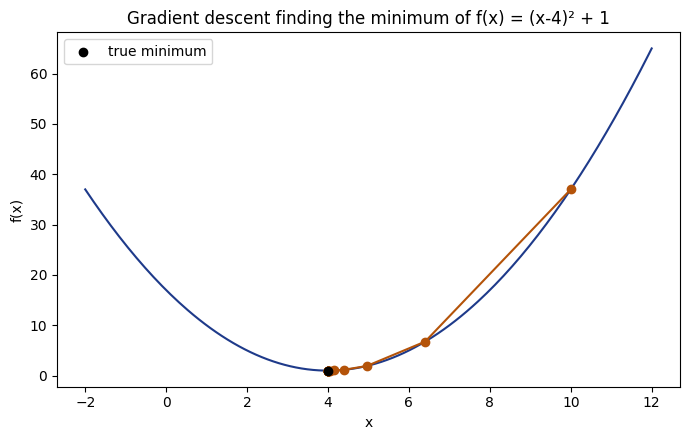

In [4]:
xs = np.linspace(-2, 12, 200)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xs, f(xs), color="#1e3a8a")
ax.plot(path, [f(v) for v in path], "o-", color="#b45309")
ax.scatter([4], [f(4)], color="black", zorder=5, label="true minimum")
ax.set_title("Gradient descent finding the minimum of f(x) = (x-4)\u00b2 + 1")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()
plt.tight_layout()
plt.show()

### The learning rate: the Goldilocks problem

The learning rate is the single most important knob to get right. **Too small, and you crawl toward
the minimum; too large, and you overshoot it &mdash; possibly forever.**

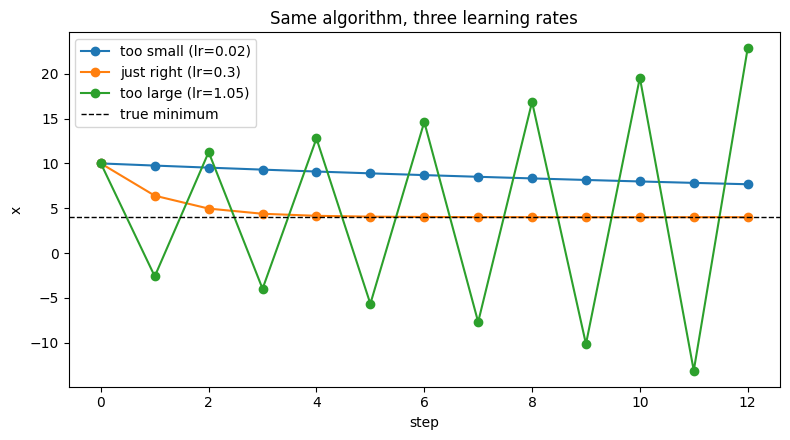

In [5]:
def run_gd(learning_rate, n_steps, x0=10.0):
    x = x0
    path = [x]
    for _ in range(n_steps):
        x = x - learning_rate * grad(x)
        path.append(x)
    return path

settings = {"too small (lr=0.02)": 0.02, "just right (lr=0.3)": 0.3, "too large (lr=1.05)": 1.05}

fig, ax = plt.subplots(figsize=(8, 4.5))
for label, lr in settings.items():
    path = run_gd(lr, 12)
    ax.plot(range(len(path)), path, "o-", label=label)
ax.axhline(4, color="black", linestyle="--", linewidth=1, label="true minimum")
ax.set_title("Same algorithm, three learning rates")
ax.set_xlabel("step")
ax.set_ylabel("x")
ax.legend()
plt.tight_layout()
plt.show()

- **Too small**: reliable, but slow &mdash; after 12 steps it's barely moved.
- **Just right**: converges quickly and stays there.
- **Too large**: overshoots the minimum every step, and the overshoot gets *worse* each time &mdash;
  this is **divergence**, and it's a real failure mode, not just slowness.

In practice you don't know the right learning rate in advance. Common strategies: start small and
scale up, try an exponential range (0.001, 0.01, 0.1, 1) and see which works, or use an adaptive
method (Adam, RMSprop) that adjusts the learning rate automatically as it trains.

### Applying it to real data: finding AAPL's beta by gradient descent

Same idea as the toy example, just with **two** parameters to search over instead of one: the
intercept $a$ and slope $b$ of AAPL's regression line, $y = a + bx$.

In Session 3, `statsmodels` gave us these directly: intercept $\approx 0.0011$, slope $\approx 1.1898$.
Let's find those same two numbers ourselves, using nothing but gradient descent on the
mean-squared-error cost function
$$MSE(a, b) = \frac{1}{n}\sum_i (a + b \cdot x_i - y_i)^2$$
whose gradients are
$$\frac{\partial MSE}{\partial a} = \frac{2}{n}\sum_i (a + b x_i - y_i), \qquad
\frac{\partial MSE}{\partial b} = \frac{2}{n}\sum_i (a + b x_i - y_i) x_i$$

**Reading this without the calculus:** $MSE(a,b)$ is just "average squared error over all $n$ days"
&mdash; the same cost the toy example minimized, now written for two parameters instead of one. Each
gradient formula is really the same shape as the toy example's $f'(x) = 2(x-4)$: "2 times the average
error." The only new piece is $\frac{\partial MSE}{\partial b}$ has an extra $x_i$ multiplied in
&mdash; that's because $b$ is the slope, so how much moving $b$ changes the prediction depends on how
big $x_i$ (the market return that day) is; days where $x_i$ is large get more say in how $b$ should
move, exactly like a regression coefficient should be more sensitive to observations further from
zero. The code below computes both formulas directly, one line each.

In [6]:
aapl = df[df["Ticker Symbol"] == "AAPL"]
x = aapl["MktReturn"].values
y = aapl["Returns"].values
n = len(x)

a, b = 0.0, 0.0          # start both parameters at zero
learning_rate = 0.5
n_iterations = 50_000

for i in range(n_iterations):
    error = (a + b * x) - y             # how wrong our current line is, for every day
    grad_a = (2 / n) * np.sum(error)          # which way to nudge the intercept
    grad_b = (2 / n) * np.sum(error * x)      # which way to nudge the slope
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b

print(f"gradient descent:  intercept = {a:.4f}, slope (beta) = {b:.4f}")
print("statsmodels (Session 3):  intercept = 0.0011, slope (beta) = 1.1898")

gradient descent:  intercept = 0.0011, slope (beta) = 1.1898
statsmodels (Session 3):  intercept = 0.0011, slope (beta) = 1.1898


Same answer, found a completely different way &mdash; by search instead of by formula. This is
exactly what's happening, at a much larger scale, whenever a neural network "trains": no closed-form
formula exists for its millions of parameters, so gradient descent (in a smarter, faster form) is
the only way to fit it.

### Types of gradient descent

The loop above used *every* observation to compute each gradient step &mdash; that's called
**batch gradient descent**. Two other variants matter in practice:

| | Uses per step | Pros | Cons |
|---|---|---|---|
| **Batch** | all $n$ observations | stable, guaranteed to reach the minimum on convex problems | slow / memory-heavy for large data |
| **Stochastic (SGD)** | 1 observation | fast, can escape shallow local minima | noisy, never fully settles |
| **Mini-batch** | a small batch (e.g. 32&ndash;256) | good balance; the standard choice in deep learning | one more hyperparameter (batch size) to tune |

**Epoch vs. iteration:**
- An **iteration** is one single parameter update (one gradient step), using one mini-batch.
- An **epoch** is one full pass through the *entire* training set &mdash; every row seen exactly once.

With mini-batches, one epoch takes several iterations. Example: our own 756 AAPL rows, batch size 100:
Iteration 1 uses rows 1&ndash;100, iteration 2 uses rows 101&ndash;200, and so on through iteration 8
(the final, smaller batch, rows 701&ndash;756) &mdash; 8 iterations to complete **1 epoch**. Training
usually runs many epochs, so the model sees each row many times, not just once.

Quick way to remember it: **epoch = a lap around the whole dataset. Iteration = one step within
that lap.**

<span style="color:#b45309">**Exercise 1: Gradient descent on another ticker**</span>

Adapt the gradient descent loop above to find GOOG's market beta (regress GOOG's `Returns` on
`MktReturn`). Try a learning rate of 0.5 with 50,000 iterations, then check your answer against a
quick `smf.ols("Returns ~ MktReturn", data=...).fit()` call.

Try it in the cell below, then check the answer notebook (`Session 4a - Exercise Answers.ipynb`).

In [7]:
# your code here


## <span style="color:#1e3a8a">Classification: predicting a category, not a number</span>

Everything so far has predicted a continuous number (a return). **Classification** predicts which
*category* an observation falls into. The core difference isn't just "the output looks different"
&mdash; it changes the whole modeling problem: instead of drawing a line/curve that fits the data as
closely as possible, the model needs to draw a **boundary** that best separates the classes. We'll
see exactly what that looks like next block, with decision trees.

- **Binary classification**: two classes, $y \in \{0, 1\}$.
  - Will a loan **default**, given the borrower's financials?
  - Is a transaction **fraudulent**, given its amount, location, and timing?
  - Will a customer **churn** (cancel) this month, given their usage history?
  - Is an email **spam**?
- **Multi-class classification**: more than two, mutually exclusive classes.
  - What **credit rating tier** (AAA, AA, A, BBB, ...) should a bond get?
  - Which **industry sector** does a company belong to, given a text description of its business?
  - What is the **sentiment** of a news headline (positive / neutral / negative)?
- **Multi-label classification**: an observation can belong to several classes at once.
  - Tagging a research report with all the **risk factors** it discusses (interest-rate risk,
    currency risk, regulatory risk &mdash; a single report can mention several).
  - Tagging a news article with multiple relevant **topics**.

Notice how many of these are genuinely consequential business decisions (loan approvals, fraud
alerts, credit ratings) &mdash; which is exactly why the evaluation questions in the next block
(not just "is it accurate" but "accurate *at what*, and what does a mistake cost") matter so much
in practice, not just in theory.

We'll focus on binary classification today, using **logistic regression** &mdash; conceptually the
most natural next step after linear regression.

### From gradient descent to logistic regression

Good news first: **the search procedure doesn't change at all.** Same loop, same idea of walking
downhill, same learning rate. Only two things change:

- **What we predict.** Linear regression predicts $a+bx$ directly &mdash; any number. Logistic
  regression squashes that same $a+bx$ through the **sigmoid function**, so the output is always a
  probability between 0 and 1.
- **What "wrong" means.** Linear regression measures wrongness with squared error. Logistic
  regression measures it with **log-loss** &mdash; a cost that's large when the model is confidently
  wrong, and small when it's right &mdash; but it's still just a number gradient descent tries to
  shrink, exactly like MSE was.

Everything else from the gradient descent section &mdash; "feel which way is downhill, take a small
step, repeat," the learning rate trade-off, batch vs. mini-batch &mdash; carries over unchanged.

## <span style="color:#1e3a8a">Logistic regression</span>

Why logistic regression and not linear regression? Linear regression can output any number, including nonsense for a probability (like $-0.3$ or
$1.7$). Logistic regression fixes this by predicting the probability that $y=1$ using the
**sigmoid function**, which squeezes any real number into $(0, 1)$:

$$P(y=1 \mid x) = \sigma(a + bx) = \frac{1}{1 + e^{-(a + bx)}}$$

- Coefficients are estimated by **maximum likelihood** (finding $a, b$ that make the observed
  0/1 labels as probable as possible under the model), not by minimizing squared error.
- The sign of a coefficient tells you the *direction* of the effect: positive means the feature
  makes $y=1$ more likely; negative, less likely. The magnitude tells you how strong that effect is.
- Predictions still come with a decision rule: predict $y=1$ if $P(y=1\mid x) \geq 0.5$ (the default
  threshold &mdash; more on why that's not always the right choice next block).

### A clean example first: hours studied vs. passing an exam

A classic, deliberately simple dataset (20 students, hours studied, pass/fail) makes the S-curve
shape obvious before we apply the same tool to noisier real data.

In [8]:
hours = np.array([0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75,
                   3, 3.25, 3.5, 4, 4.25, 4.5, 4.75, 5, 5.5, 6]).reshape(-1, 1)
passed = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

exam_model = LogisticRegression()
exam_model.fit(hours, passed)
print(f"coefficient: {exam_model.coef_[0][0]:.3f}   intercept: {exam_model.intercept_[0]:.3f}")
print(f"training accuracy: {exam_model.score(hours, passed):.2f}")

coefficient: 1.080   intercept: -3.192
training accuracy: 0.80


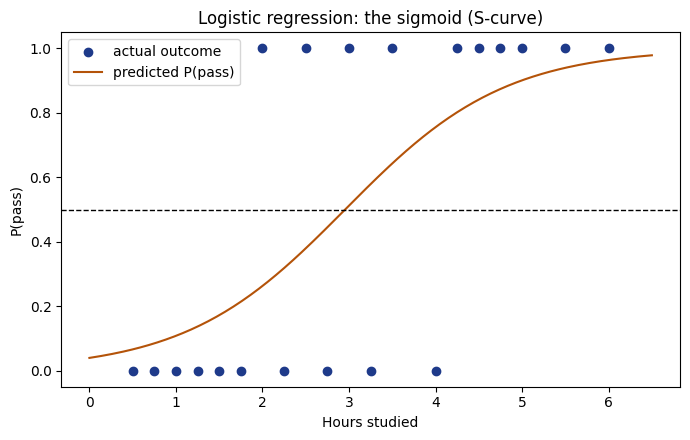

In [9]:
hours_grid = np.linspace(0, 6.5, 200).reshape(-1, 1)
prob_grid = exam_model.predict_proba(hours_grid)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(hours, passed, color="#1e3a8a", label="actual outcome")
ax.plot(hours_grid, prob_grid, color="#b45309", label="predicted P(pass)")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Hours studied")
ax.set_ylabel("P(pass)")
ax.set_title("Logistic regression: the sigmoid (S-curve)")
ax.legend()
plt.tight_layout()
plt.show()

The decision boundary &mdash; where predicted probability crosses 0.5 &mdash; sits at about
$-\text{intercept}/\text{coefficient} \approx 3$ hours, matching the visual crossover point.

### Now on real data: will AAPL be up today, given the market's move?

Same tool, our own dataset: predict whether AAPL's `Returns` are positive (an "up day") from
`MktReturn`. One adjustment first: `MktReturn` is tiny (daily moves are usually under 1%, i.e.
under 0.01), and scikit-learn's logistic regression penalizes large coefficients by default
(regularization). A tiny-scale feature needs a *huge* coefficient to have any effect, and that
penalty crushes it before it gets there. The fix: rescale `MktReturn` into **percentage points**
(multiply by 100) before fitting &mdash; same information, better-behaved scale.

In [10]:
aapl = aapl.copy()
aapl["UpDay"] = (aapl["Returns"] > 0).astype(int)
aapl["MktReturnPct"] = aapl["MktReturn"] * 100     # rescale: decimal -> percentage points

X = aapl[["MktReturnPct"]].values
y = aapl["UpDay"].values

model = LogisticRegression()
model.fit(X, y)

print(f"coefficient: {model.coef_[0][0]:.3f}   intercept: {model.intercept_[0]:.3f}")
print(f"odds ratio:  {np.exp(model.coef_[0][0]):.2f}")
print(f"accuracy:    {model.score(X, y):.3f}")
print(f"base rate (always predict 'up'): {y.mean():.3f}")

coefficient: 1.867   intercept: 0.068
odds ratio:  6.47
accuracy:    0.763
base rate (always predict 'up'): 0.546


#### Odds ratio

A simple example first. Suppose normally there's a 50% chance of rain &mdash; a coin flip, so the
**odds** of rain are 1-to-1 (odds = 1). Now suppose overcast skies double those odds: odds go from
1 to 2 (2-to-1 *in favor* of rain), which works out to a 67% chance of rain. That multiplier, **2**,
is the odds ratio: overcast skies multiply the odds of rain by 2 &mdash; whatever the starting odds
were. Odds ratios are always about this kind of *multiplying*, not adding percentage points.

In logistic regression, the odds ratio for a feature is $e^{\text{coefficient}}$: how much the odds
of $y=1$ multiply for a 1-unit increase in that feature. Here, $e^{1.867} \approx 6.47$ &mdash; a
1-percentage-point increase in the market's return multiplies the odds of an AAPL up-day by about
6.47&times;. A realistic-sized move (1 percentage point) now maps to a realistic-sounding number.

#### Training accuracy

The share of predictions the model gets right, evaluated on the same data it was fit on. Here,
0.763 &mdash; the model correctly classifies 76.3% of days as up or down.

#### Base rate

The accuracy you'd get from the dumbest possible model: always predict the majority class, and
ignore `x` entirely. Here, AAPL closed up on 54.6% of days, so simply *always guessing "up"* already
gets 54.6% accuracy. A model's accuracy only means something relative to this baseline &mdash; 76.3%
against a 54.6% base rate means the model is genuinely picking up a real, usable signal.

The coefficient is positive, and this classifier genuinely works &mdash; 76.3% accuracy against a
54.6% base rate is a real, meaningful improvement, not noise. That direction also makes complete
sense given last block's beta: AAPL and the market move together, so knowing which way the market
moved is real evidence about which way AAPL moved.

### For comparison: AAPL, unscaled

We described the unscaled version above without actually showing it. Here it is: the exact same
AAPL up-day model, without the percentage-point rescale.

In [11]:
X_unscaled = aapl[["MktReturn"]].values     # unscaled, on purpose
y = aapl["UpDay"].values

model_unscaled = LogisticRegression()
model_unscaled.fit(X_unscaled, y)

print(f"coefficient: {model_unscaled.coef_[0][0]:.3f}   odds ratio: {np.exp(model_unscaled.coef_[0][0]):.2f}")
print(f"accuracy:    {model_unscaled.score(X_unscaled, y):.3f}")
print(f"base rate:   {y.mean():.3f}")

coefficient: 2.548   odds ratio: 12.79
accuracy:    0.550
base rate:   0.546


**Reading this honestly:** same data, same target, same model &mdash; the only thing that changed
between this cell and the rescaled version above is the scale of one input column, and accuracy
moved from 0.550 (barely above the 0.546 base rate) to 0.763. Odds ratio moved from a misleadingly
huge 12.79&times; to a believable 6.47&times;. Nothing about AAPL, the market, or the relationship
between them changed &mdash; only how "expensive" that relationship was to represent, in a
regularized model's eyes. That's the entire lesson of this block in one side-by-side comparison:
always check your feature scales before trusting (or dismissing) a model's result.

## <span style="color:#1e3a8a">Looking ahead</span>

We now have two building blocks: an optimization engine (gradient descent) and a way to predict
categories (logistic regression), plus a hard-won lesson about feature scaling that applies to
almost every model we'll touch from here on. Next block: a completely different kind of classifier
(decision trees), and a case where accuracy *does* actively mislead you, even with well-scaled data
&mdash; and what to do about it.